# Metrics comparison between symbolic and numerical IK control

## Imports 

In [2]:
import ast
import numpy as np
import pandas as pd
# import matplotlib
# matplotlib.use("TkAgg")
import matplotlib.pyplot as plt
from metrics import l2_error, rodrigues_error


In [3]:
test = "heart" # line, circle, heart

filepath_sym = f'data/sym_{test}_data.csv'
filepath_num = f'data/num_{test}_data.csv'
filepath_qp = f'data/qp_{test}_data.csv'

df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()
df_qp = pd.read_csv(filepath_qp, sep=",", header=0).copy()

display(df_sym.head(3))
df_sym.info()
df_num.info()

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,r_q2,r_q3,r_q4,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose
0,0.000000,-45.699365,20.268327,-2.110257,-71.943844,-4.892438,30.507757,32.685959,-45.699365,-20.268327,2.110257,-71.943844,4.892438,30.507757,-32.685959,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-8.829793013420684e-08, 1.9259936492786662e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.0934805135809356e-06, 1.2327074713834926e..."
1,0.008333,-45.631070,20.417319,-1.974118,-71.878657,-5.099069,30.364675,32.793080,-45.631070,-20.417319,1.974118,-71.878657,5.099069,30.364675,-32.793080,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.587942307090806e-07, 1.9465170048269614e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.1665594594201245e-06, 1.2113836696891434e..."
2,0.016667,-45.569813,20.568503,-1.838041,-71.812144,-5.309354,30.226705,32.901858,-45.569813,-20.568503,1.838041,-71.812144,5.309354,30.226705,-32.901858,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-4.108314249906542e-08, 1.893748377281043e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.0514340787470822e-06, 1.2633796494607578e..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         1440 non-null   float64
 1   l_q0         1440 non-null   float64
 2   l_q1         1440 non-null   float64
 3   l_q2         1440 non-null   float64
 4   l_q3         1440 non-null   float64
 5   l_q4         1440 non-null   float64
 6   l_q5         1440 non-null   float64
 7   l_q6         1440 non-null   float64
 8   r_q0         1440 non-null   float64
 9   r_q1         1440 non-null   float64
 10  r_q2         1440 non-null   float64
 11  r_q3         1440 non-null   float64
 12  r_q4         1440 non-null   float64
 13  r_q5         1440 non-null   float64
 14  r_q6         1440 non-null   float64
 15  l_pose       1440 non-null   object 
 16  l_real_pose  1440 non-null   object 
 17  r_pose       1440 non-null   object 
 18  r_real_pose  1440 non-null   object 
dtypes: flo

In [4]:
def parse_pose_matrix(matrix_str):
    """Convert a string of a matrix into a NumPy array."""
    return np.array(ast.literal_eval(matrix_str))

In [5]:
l_pos_errs, l_rot_errs, = [], []
r_pos_errs, r_rot_errs, = [], []

for _, row in df_sym.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])
    
    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_sym["l_pos_err"] = l_pos_errs
df_sym["l_rot_err"] = l_rot_errs

df_sym["r_pos_err"] = r_pos_errs
df_sym["r_rot_err"] = r_rot_errs

display(df_sym.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,r_pos_err,r_rot_err
0,0.000000,-45.699365,20.268327,-2.110257,-71.943844,-4.892438,30.507757,32.685959,-45.699365,-20.268327,...,30.507757,-32.685959,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-8.829793013420684e-08, 1.9259936492786662e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.0934805135809356e-06, 1.2327074713834926e...",3.638444e-07,0.000002,2.973397e-07,0.000002
1,0.008333,-45.631070,20.417319,-1.974118,-71.878657,-5.099069,30.364675,32.793080,-45.631070,-20.417319,...,30.364675,-32.793080,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.587942307090806e-07, 1.9465170048269614e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.1665594594201245e-06, 1.2113836696891434e...",3.834381e-07,0.000002,3.243645e-07,0.000002
2,0.016667,-45.569813,20.568503,-1.838041,-71.812144,-5.309354,30.226705,32.901858,-45.569813,-20.568503,...,30.226705,-32.901858,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-4.108314249906542e-08, 1.893748377281043e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.0514340787470822e-06, 1.2633796494607578e...",3.524403e-07,0.000002,2.925798e-07,0.000002


In [6]:
l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_num.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_num["l_pos_err"] = l_pos_errs
df_num["l_rot_err"] = l_rot_errs

df_num["r_pos_err"] = r_pos_errs
df_num["r_rot_err"] = r_rot_errs

l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
r_pos_errs, r_rot_errs, r_comb_errs = [], [], []

for _, row in df_qp.iterrows():
    l_pose = parse_pose_matrix(row["l_pose"])
    l_real = parse_pose_matrix(row["l_real_pose"])

    l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
    l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

    l_pos_errs.append(l_pos)
    l_rot_errs.append(l_rot)

    r_pose = parse_pose_matrix(row["r_pose"])
    r_real = parse_pose_matrix(row["r_real_pose"])

    r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
    r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

    r_pos_errs.append(r_pos)
    r_rot_errs.append(r_rot)

df_qp["l_pos_err"] = l_pos_errs
df_qp["l_rot_err"] = l_rot_errs

df_qp["r_pos_err"] = r_pos_errs
df_qp["r_rot_err"] = r_rot_errs

display(df_num.head(3))

,time,l_q0,l_q1,l_q2,l_q3,l_q4,l_q5,l_q6,r_q0,r_q1,...,r_q5,r_q6,l_pose,l_real_pose,r_pose,r_real_pose,l_pos_err,l_rot_err,r_pos_err,r_rot_err
0,0.000000,-47.166548,7.715591,15.077701,-71.943831,-6.980102,32.333060,12.333161,-47.154274,-7.760825,...,32.325195,-12.409106,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[4.0257409700261704e-07, -1.122800035856234e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[1.1453916149983812e-06, 4.274503319923802e-0...",2.417304e-07,4.133434e-07,7.426792e-07,0.000001
1,0.008333,-47.137137,7.845570,15.253718,-71.878814,-7.226169,32.265336,12.410303,-47.124760,-7.890560,...,32.257300,-12.486114,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-5.740029040968153e-08, -3.632758448614969e-...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-6.718839851149738e-08, 1.9298926046665952e-...",1.797586e-05,3.707929e-07,2.235293e-04,0.000002
2,0.016667,-47.114870,7.978119,15.429833,-71.812431,-7.473713,32.203837,12.488045,-47.102361,-8.022924,...,32.195572,-12.563763,"[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[3.588182895253311e-08, -5.374344606449125e-0...","[[2.220446049250313e-16, -0.0, -1.0, 0.55], [0...","[[-1.5592882762760496e-07, 1.4701079670172101e...",2.978907e-05,5.437881e-07,1.351687e-04,0.000001


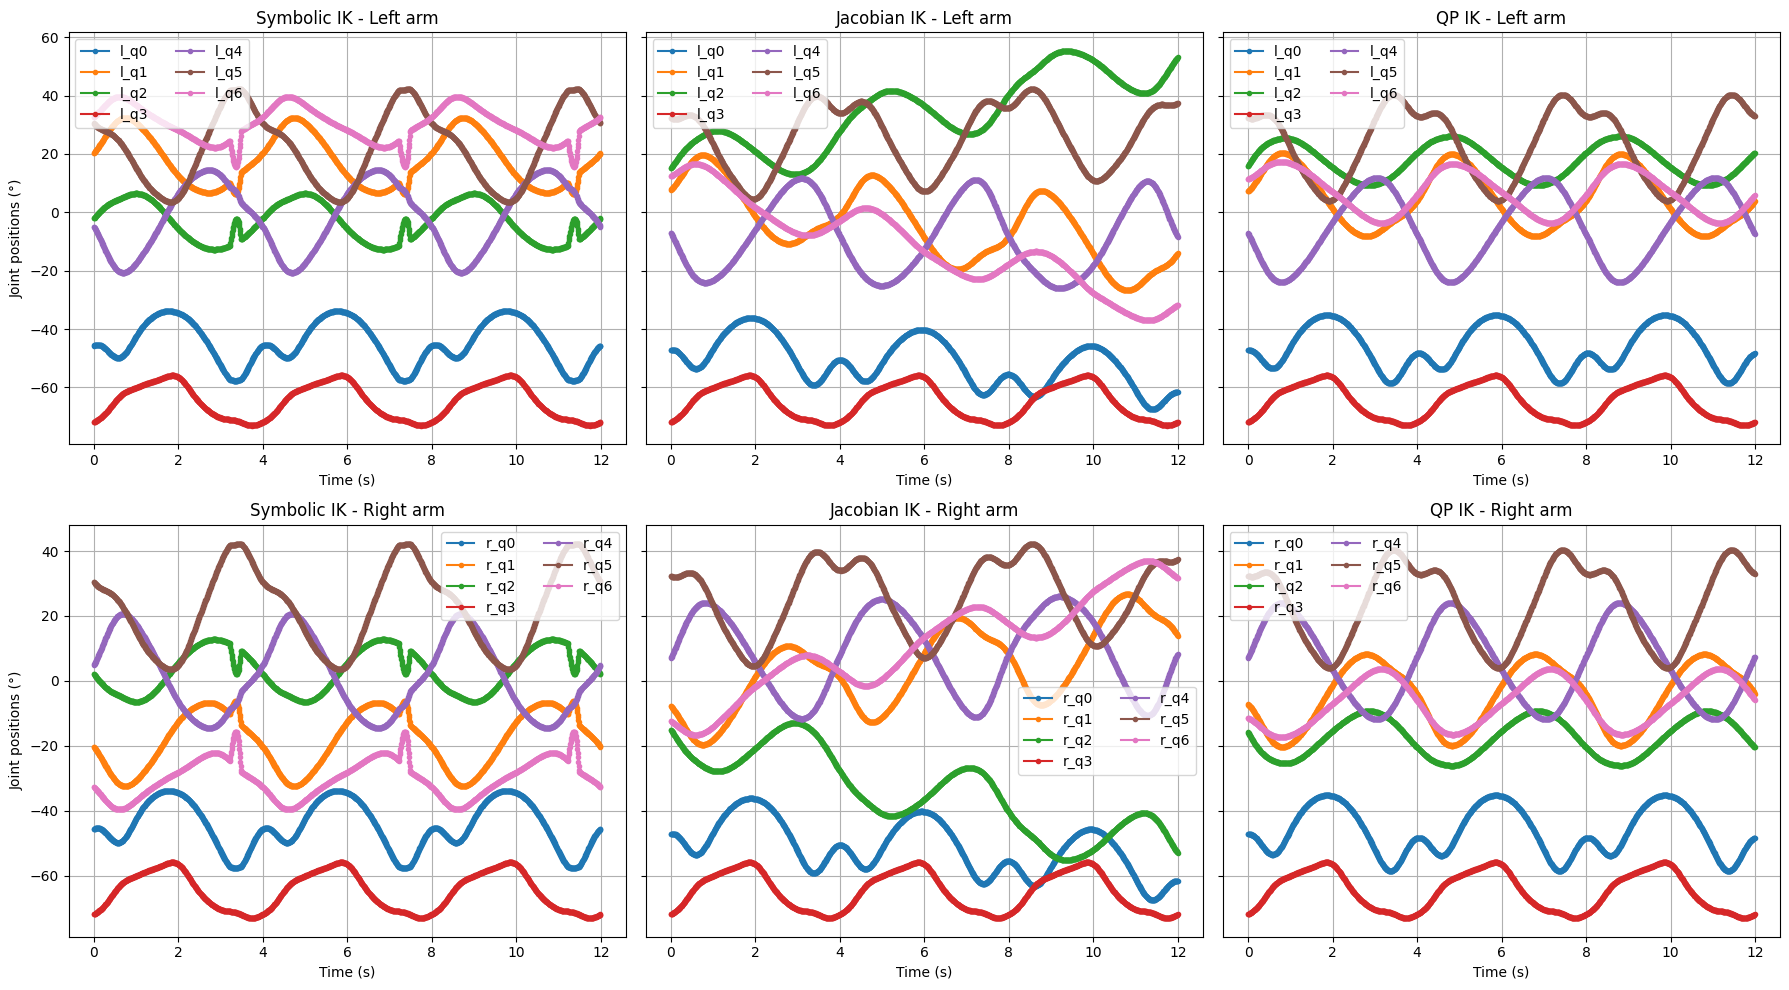

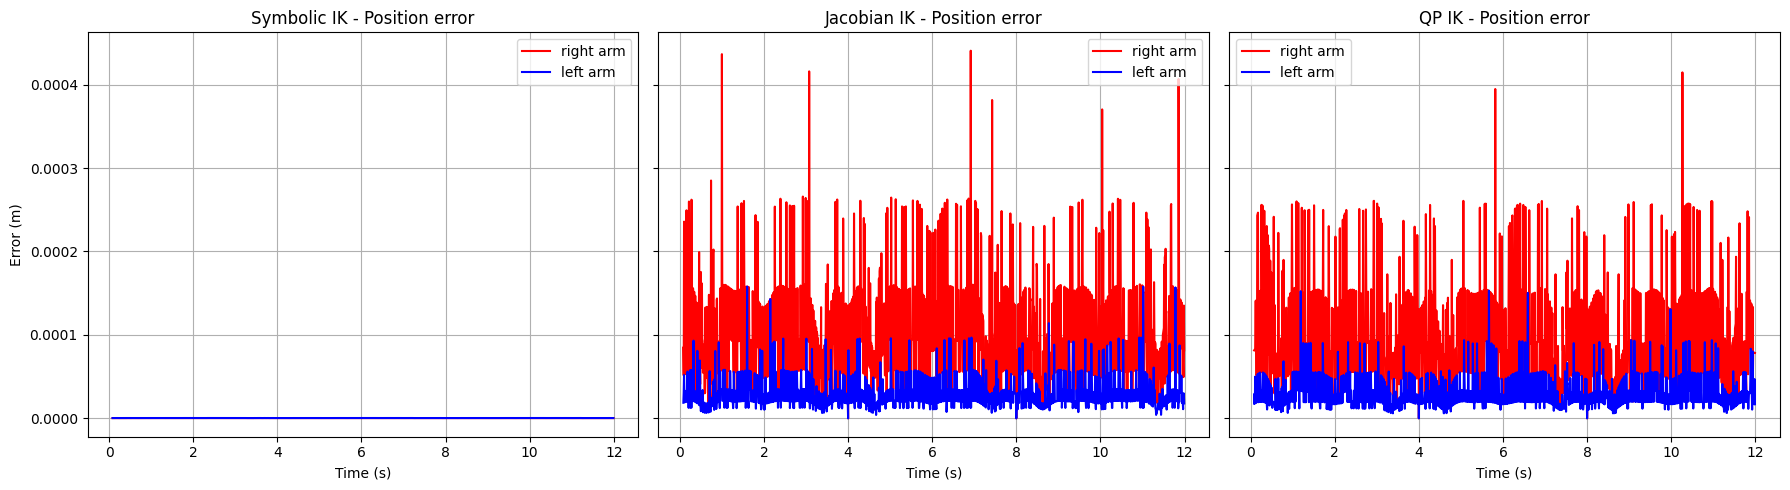

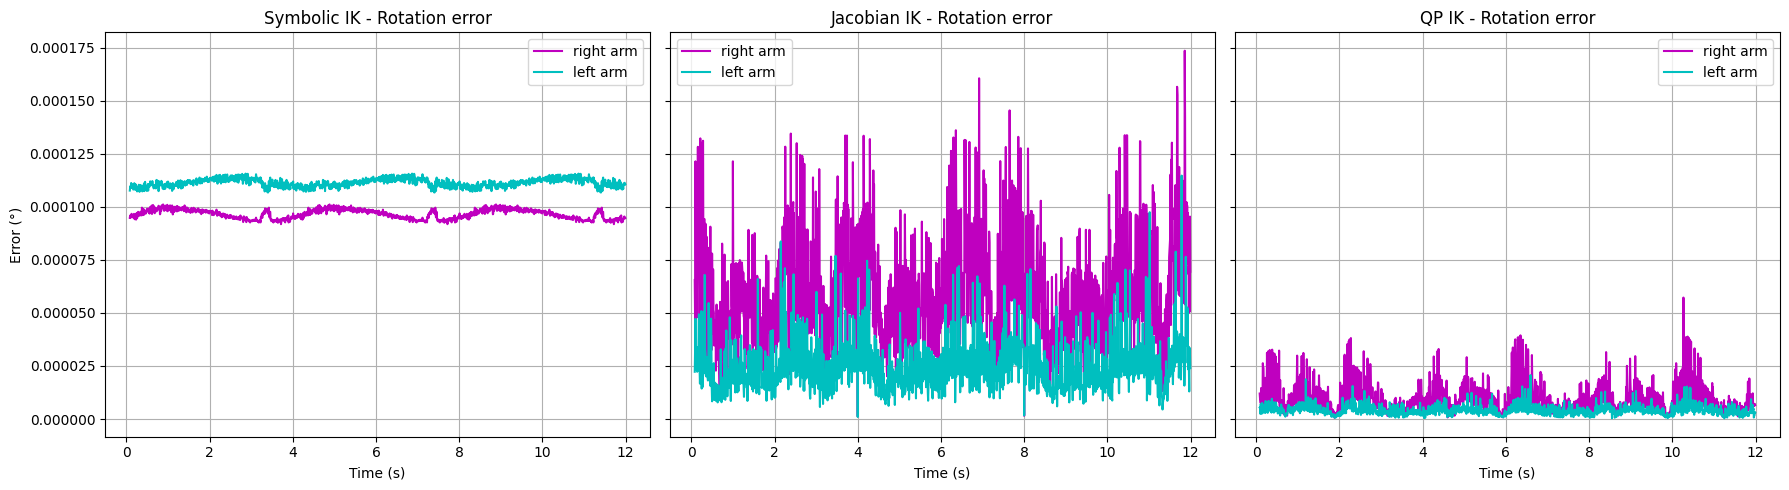

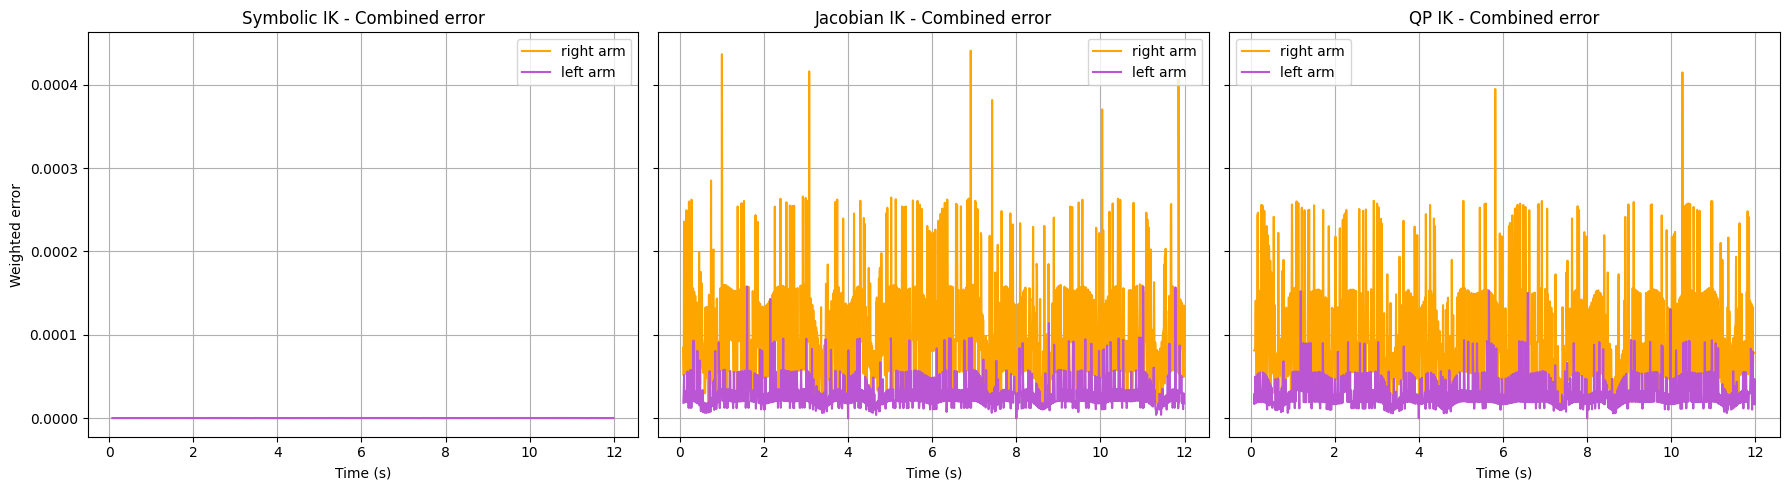

In [7]:
dfs = [(df_sym, 'Symbolic IK'), (df_num, 'Jacobian IK'), (df_qp, 'QP IK')]
l_cols = [f'l_q{i}' for i in range(7)]
r_cols = [f'r_q{i}' for i in range(7)]

time_slice = slice(10, None)
lambda_theta = 1e-6 / np.deg2rad(1)**2

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey='row')
for idx, (df, title) in enumerate(dfs):
    for col in l_cols:
        axes[0, idx].plot(df['time'], df[col], marker='.')
    axes[0, idx].set_title(f"{title} - Left arm")
    axes[0, idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[0, idx].set_ylabel("Joint positions (°)")
    axes[0, idx].grid(True)
    axes[0, idx].legend(l_cols, ncol=2)

    for col in r_cols:
        axes[1, idx].plot(df['time'], df[col], marker='.')
    axes[1, idx].set_title(f"{title} - Right arm")
    axes[1, idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[1, idx].set_ylabel("Joint positions (°)")
    axes[1, idx].grid(True)
    axes[1, idx].legend(r_cols, ncol=2)

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    axes[idx].plot(df['time'][time_slice], df['r_pos_err'][time_slice], label='right arm', color='red')
    axes[idx].plot(df['time'][time_slice], df['l_pos_err'][time_slice], label='left arm', color='blue')
    axes[idx].set_title(f"{title} - Position error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Error (m)")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    axes[idx].plot(df['time'][time_slice], np.rad2deg(df['r_rot_err'][time_slice]), label='right arm', color='m')
    axes[idx].plot(df['time'][time_slice], np.rad2deg(df['l_rot_err'][time_slice]), label='left arm', color='c')
    axes[idx].set_title(f"{title} - Rotation error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Error (°)")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df, title) in enumerate(dfs):
    comb_l = np.sqrt(df['l_pos_err']**2 + (lambda_theta * df['l_rot_err']**2))
    comb_r = np.sqrt(df['r_pos_err']**2 + (lambda_theta * df['r_rot_err']**2))
    axes[idx].plot(df['time'][time_slice], comb_r[time_slice], label='right arm', color='orange')
    axes[idx].plot(df['time'][time_slice], comb_l[time_slice], label='left arm', color='mediumorchid')
    axes[idx].set_title(f"{title} - Combined error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Weighted error")
    axes[idx].legend()
    axes[idx].grid(True)
fig.tight_layout()
plt.show()


## Parameters influence 

### Proportionnal corrector $K_p$

In [8]:
method = "num"

mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for kp in ["0010", "0025", "0050", "0075", "0100", "0125", "0150", "0175", "0200", "0300", "0400", "0500", "0600", "0750", "1000"]:
    filepath_num = f'data/{method}_circle_data_kp{kp}.csv'
    df_num2 = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num2.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())
    

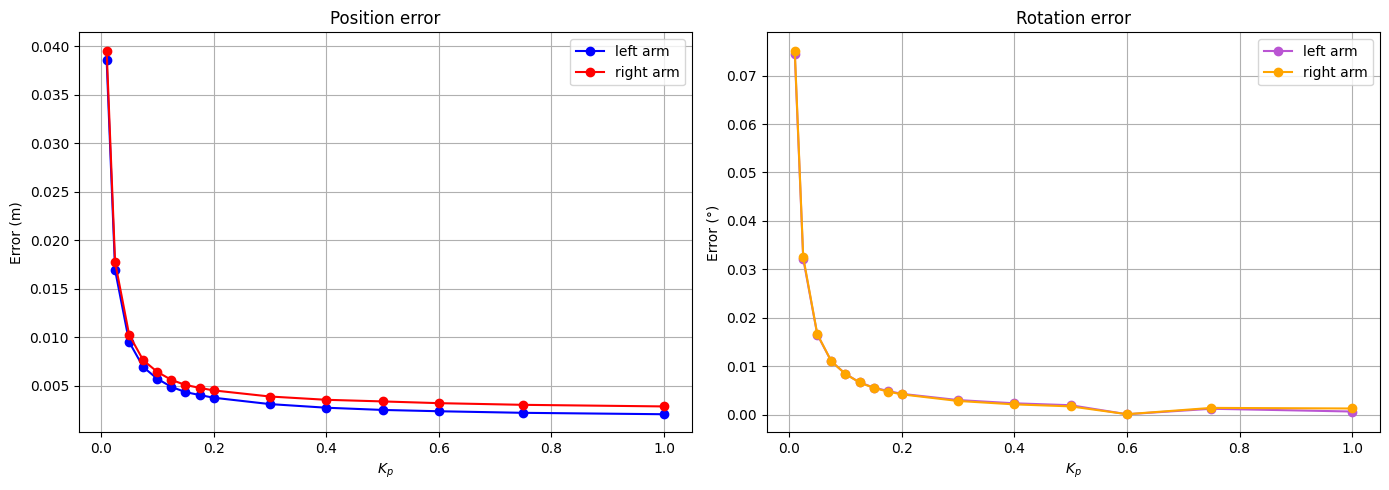

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Kp = [0.01, 0.025, 0.050, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.3, 0.4, 0.5, 0.6, 0.75, 1.0]

axes[0].plot(Kp, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(Kp, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("$K_p$")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(Kp, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(Kp, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("$K_p$")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


Integration step `ik_step` 

In [10]:

mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for step in ["00010", "00020", "00030", "00040", "00050"]:
    filepath_num = f'data/num_circle_data_ikstep{step}.csv'
    df_num2 = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num2.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())
    

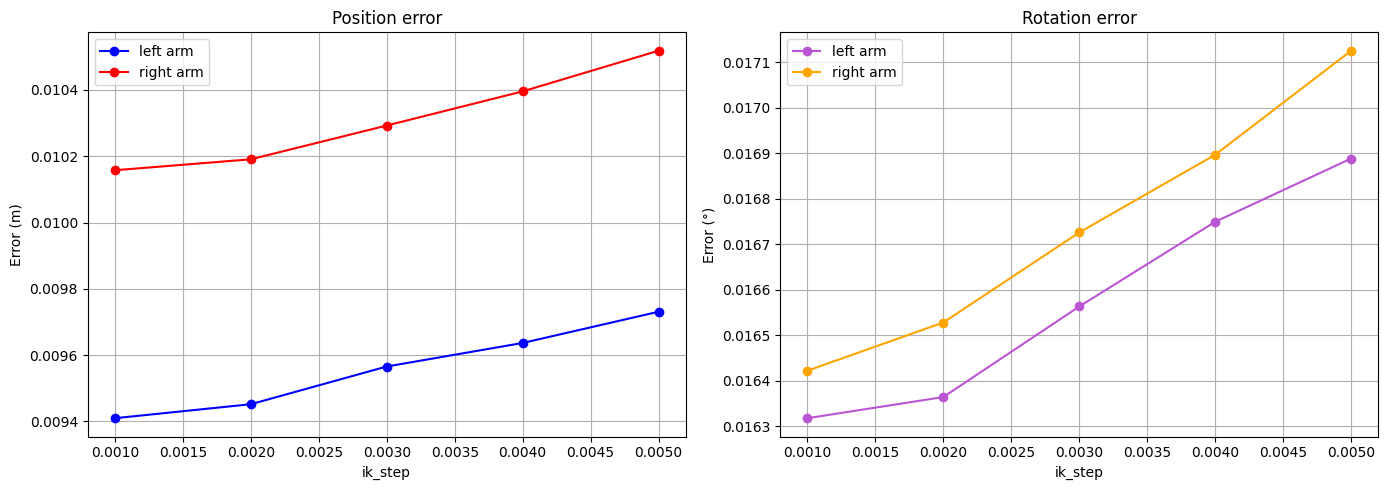

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

step = [0.001, 0.002, 0.003, 0.004, 0.005]

axes[0].plot(step, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(step, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("ik_step")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(step, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(step, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("ik_step")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


### Damping factor $\lambda$

In [12]:

mean_l_pos_err, mean_r_pos_err = [], []
mean_l_rot_err, mean_r_rot_err = [], []

for step in ["075e10", "075e9", "075e8", "075e7", "075e6", "075e5", "075e4", "075e3", "075e2", "075e1"]:
    filepath_num = f'data/num_circle_data_l{step}.csv'
    df_num2 = pd.read_csv(filepath_num, sep=",", header=0).copy()

    l_pos_errs, l_rot_errs, l_comb_errs = [], [], []
    r_pos_errs, r_rot_errs, r_comb_errs = [], [], []
    for _, row in df_num2.iterrows():
        l_pose = parse_pose_matrix(row["l_pose"])
        l_real = parse_pose_matrix(row["l_real_pose"])

        l_pos = l2_error(l_pose[:3, 3], l_real[:3, 3])
        l_rot = rodrigues_error(l_pose[:3, :3], l_real[:3, :3])

        l_pos_errs.append(l_pos)
        l_rot_errs.append(l_rot)

        r_pose = parse_pose_matrix(row["r_pose"])
        r_real = parse_pose_matrix(row["r_real_pose"])

        r_pos = l2_error(r_pose[:3, 3], r_real[:3, 3])
        r_rot = rodrigues_error(r_pose[:3, :3], r_real[:3, :3])

        r_pos_errs.append(r_pos)
        r_rot_errs.append(r_rot)

    mean_l_pos_err.append(np.array(l_pos_errs).mean())
    mean_r_pos_err.append(np.array(r_pos_errs).mean())
    mean_l_rot_err.append(np.array(l_rot_errs).mean())
    mean_r_rot_err.append(np.array(r_rot_errs).mean())
    

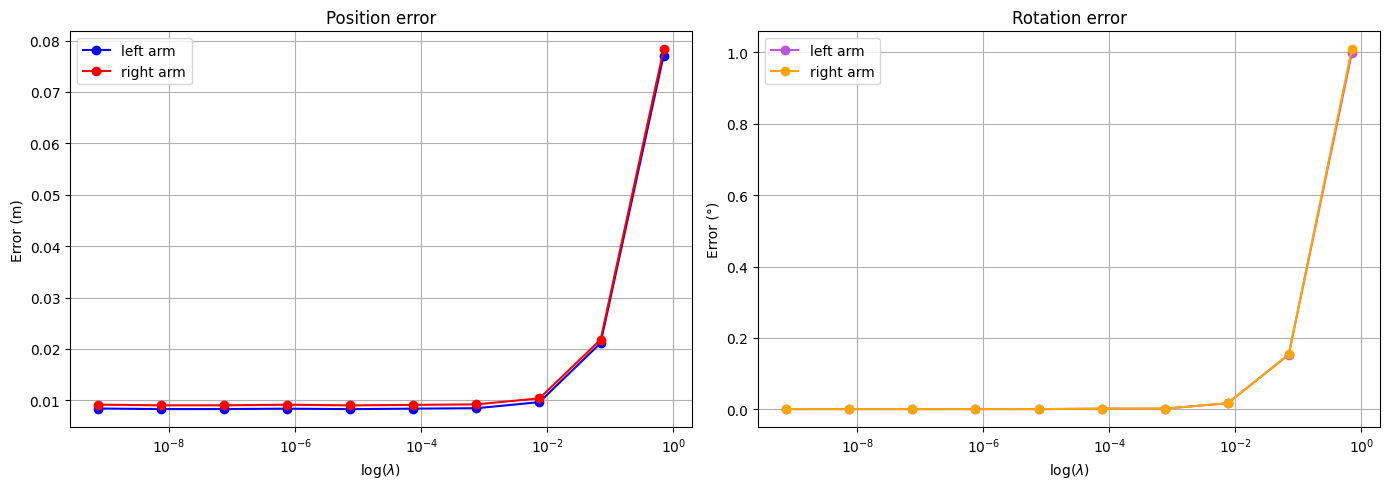

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_lambda = [7.5e-10, 7.5e-9, 7.5e-8, 7.5e-7, 7.5e-6, 7.5e-5, 7.5e-4, 7.5e-3, 7e-2, 7e-1]

axes[0].plot(_lambda, mean_l_pos_err, label="left arm", color="b", marker="o")
axes[0].plot(_lambda, mean_r_pos_err, label="right arm", color="r", marker="o")
axes[0].set_title("Position error")
axes[0].set_ylabel("Error (m)")
axes[0].set_xlabel("$\\log(\\lambda)$")
axes[0].set_xscale('log')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(_lambda, np.rad2deg(mean_l_rot_err), label="left arm", color="mediumorchid", marker="o")
axes[1].plot(_lambda, np.rad2deg(mean_r_rot_err), label="right arm", color="orange", marker="o")
axes[1].set_title("Rotation error")
axes[1].set_ylabel("Error (°)")
axes[1].set_xlabel("$\\log(\\lambda)$")
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 3D Trajectories

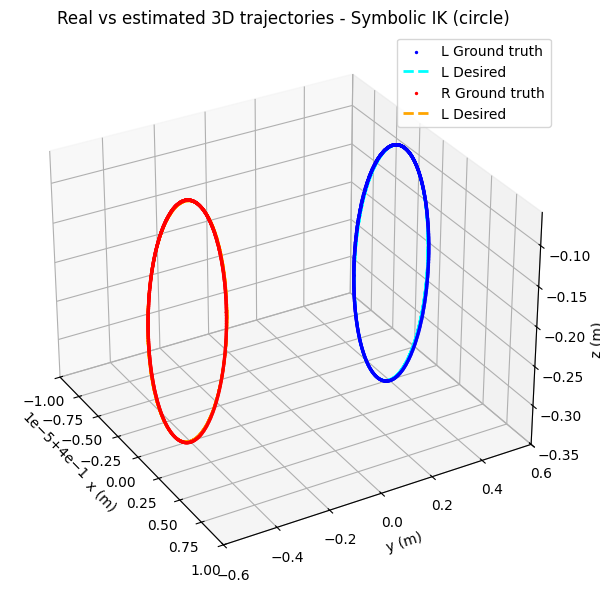

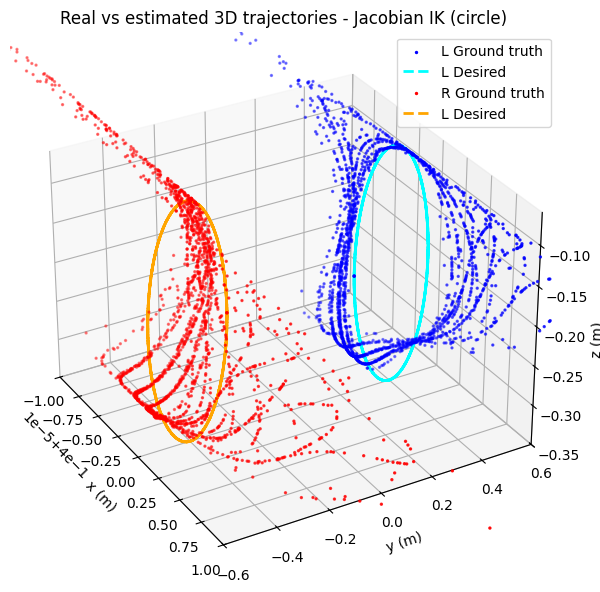

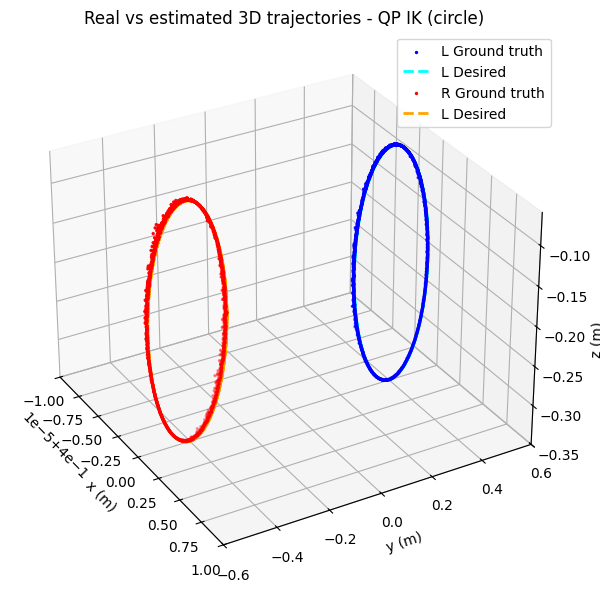

In [17]:
from mpl_toolkits.mplot3d import Axes3D


test = "circle" # line, circle, heart

filepath_sym = f'data/sym_{test}_data.csv'
filepath_num = f'data/num_{test}_data.csv'
filepath_qp = f'data/qp_{test}_data.csv'

df_sym = pd.read_csv(filepath_sym, sep=",", header=0).copy()
df_num = pd.read_csv(filepath_num, sep=",", header=0).copy()
df_qp = pd.read_csv(filepath_qp, sep=",", header=0).copy()


if test == "line":
    elev = 30
    azim = -30
    xlim = [0.39999, 0.40001]
    ylim = [-0.5, 0.5]
    zlim = [-(2e-1-3e-7), -(2e-1+3e-7)]
elif test == "heart":
    elev = 30
    azim = -45
    xlim = [0.54999, 0.55001]
    ylim = [-0.4, 0.4]
    zlim = [-0.2, 0.05]
elif test == "circle":
    elev = 30
    azim = -30
    xlim = [0.39999, 0.40001]
    ylim = [-0.6, 0.6]
    zlim = [-0.35, -0.06]

def extract_trajectory(df, col_name):
    xs, ys, zs = [], [], []
    for pose_str in df[col_name]:
        pose = parse_pose_matrix(pose_str)
        x, y, z = pose[:3, 3]
        xs.append(x)
        ys.append(y)
        zs.append(z)
    return xs, ys, zs


for name, df in zip(["Symbolic IK", "Jacobian IK", "QP IK"], [df_sym, df_num, df_qp]):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=elev, azim=azim)

    l_x_gth, l_y_gth, l_z_gth = extract_trajectory(df, "l_real_pose")
    l_x_des, l_y_des, l_z_des = extract_trajectory(df, "l_pose")

    r_x_gth, r_y_gth, r_z_gth = extract_trajectory(df, "r_real_pose")
    r_x_des, r_y_des, r_z_des = extract_trajectory(df, "r_pose")

    ax.scatter(l_x_gth, l_y_gth, l_z_gth, label="L Ground truth", color='blue', s=2)
    ax.plot(l_x_des, l_y_des, l_z_des, label="L Desired", linestyle='--', color='cyan', linewidth=2)

    ax.scatter(r_x_gth, r_y_gth, r_z_gth, label="R Ground truth", color='red', s=2)
    ax.plot(r_x_des, r_y_des, r_z_des, label="L Desired", linestyle='--', color='orange', linewidth=2)

    ax.set_title(f"Real vs estimated 3D trajectories - {name} ({test})")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_zlabel("z (m)")
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.set_zlim(zlim[0], zlim[1])

    ax.legend()
    plt.tight_layout()
    ax.grid(True)
    plt.show()